В рамках исследования контролируемых трансформаций изображений подготовлен сопроводительный экспериментальный код (Jupyter Notebook), реализующий сравнительную оценку различных групп методов аугментации на наборе данных CIFAR‑10 с использованием архитектуры ResNet‑18.  
  
В ходе экспериментов сопоставляются следующие категории преобразований:  
1. геометрические;
1. фотометрические (цветовые и яркостные);
1. шумовые;
1. структурно‑регуляризационные;
1. генеративно‑подобные (синтезированные) помехи;
1. комбинированные стратегии аугментации.
  
Помимо стандартной точности на чистых изображениях, оценивается устойчивость моделей к искажениям с помощью модифицированных тестовых наборов, содержащих:  
* аддитивный шум;
* размытие;
* эффекты тумана и погодных условий;
* искажения яркости.
  
Цель экспериментов – анализ компромисса между точностью классификации, обобщающей способностью и устойчивостью к возмущениям. 

## Установка библиотек и настройка окружения

In [1]:
# !pip install -q albumentations==1.4.8

In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

## Конфигурация эксперимента

В экспериментах используются:

- набор данных CIFAR‑10;
- архитектура ResNet‑18, адаптированная под разрешение CIFAR;
- оптимизатор Adam;
- ранняя остановка (early stopping);
- планировщик ReduceLROnPlateau;
- фиксированные начальные значения генераторов случайных чисел для воспроизводимости.

Оценка выполняется на:

- исходном чистом тестовом наборе;
- наборах с искажениями для проверки робастности.

In [3]:
SEED = 42
BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 8
VAL_SPLIT = 0.2
NUM_CLASSES = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)

Using device: cuda


# Конвейеры аугментации

Независимо оцениваются следующие группы аугментаций:

| Группа | Назначение |
|---|---|
| Без аугментации (Baseline) | Исходные данные без преобразований |
| Геометрические (Geometry) | Пространственная инвариантность |
| Фотометрические (Photometric) | Устойчивость к освещению и цвету |
| Шумовые (Noise) | Робастность к помехам и сжатию |
| Структурные (Structural) | Регуляризация |
| Генеративно-подобные (Generative-like) | Имитация погодных условий и доменных искажений |
| Комбинированные (Combined) | Смешанная стратегия дополнения |

Интенсивность преобразований намеренно выбрана умеренной, чтобы избежать семантического разрушения изображений CIFAR‑10.

In [4]:
augmentations = {

    "baseline": A.Compose([
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "geometry": A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            translate_percent=(0.03, 0.03),
            rotate=(-12, 12),
            shear=(-3, 3),
            p=0.7
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "photometric": A.Compose([
        A.RandomBrightnessContrast(
            brightness_limit=0.12,
            contrast_limit=0.12,
            p=0.6
        ),
        A.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
            hue=0.03,
            p=0.4
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "noise": A.Compose([
        A.GaussNoise(
            std_range=(0.01, 0.04),
            p=0.4
        ),
        A.GaussianBlur(
            blur_limit=(3, 3),
            p=0.2
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "structural": A.Compose([
        A.CoarseDropout(
            num_holes_range=(1, 1),
            hole_height_range=(0.10, 0.18),
            hole_width_range=(0.10, 0.18),
            fill=0,
            p=0.35
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "generative_like": A.Compose([
        A.OneOf([
            A.RandomFog(
                fog_coef_range=(0.05, 0.12),
                alpha_coef=0.05,
                p=1.0
            ),
            A.RandomRain(
                brightness_coefficient=0.97,
                blur_value=3,
                p=1.0
            ),
            A.RandomShadow(
                shadow_roi=(0, 0.5, 1, 1),
                num_shadows_limit=(1, 2),
                p=1.0
            ),
        ], p=0.35),
        A.ImageCompression(
            quality_range=(60, 90),
            p=0.2
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "combined": A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(
            scale=(0.95, 1.05),
            rotate=(-10, 10),
            p=0.4
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.1,
            contrast_limit=0.1,
            p=0.4
        ),
        A.GaussNoise(
            std_range=(0.01, 0.03),
            p=0.2
        ),
        A.CoarseDropout(
            num_holes_range=(1, 1),
            hole_height_range=(0.08, 0.12),
            hole_width_range=(0.08, 0.12),
            p=0.2
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ])
}

In [5]:
class CIFAR10Albumentations(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        image = np.array(image)
        transformed = self.transform(image=image)
        return transformed["image"], label

# Модель нейронной сети

Используется модифицированная архитектура ResNet‑18.

Первый свёрточный слой и операция max‑pooling адаптированы под разрешение изображений CIFAR‑10 (32×32).

In [6]:
def get_model():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(
        model.fc.in_features,
        NUM_CLASSES
    )
    return model.to(DEVICE)

In [7]:
def train_model(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=2
    )

    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        loop = tqdm(train_loader, leave=False)

        for images, labels in loop:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = 100.0 * correct / total
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(best_model_state)

    return model, history

def evaluate_model(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    return 100 * correct / total

# Оценка устойчивости модели

Устойчивость модели оценивается на искажённых версиях тестового набора CIFAR‑10.

Используются следующие типы искажений:
- аддитивный гауссов шум;
- размытие;
- имитация тумана и погодных условий;
- искажение яркости.

Чистый тестовый набор при оценивании никогда не подвергается аугментации.

In [8]:
robustness_transforms = {

    "clean": A.Compose([
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "noise": A.Compose([
        A.GaussNoise(
            std_range=(0.04, 0.08),
            p=1.0
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "blur": A.Compose([
        A.GaussianBlur(
            blur_limit=(3, 5),
            p=1.0
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "fog": A.Compose([
        A.RandomFog(
            fog_coef_range=(0.15, 0.25),
            alpha_coef=0.08,
            p=1.0
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ]),

    "brightness": A.Compose([
        A.RandomBrightnessContrast(
            brightness_limit=0.25,
            contrast_limit=0.15,
            p=1.0
        ),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2()
    ])
}

In [9]:
def denormalize(img_tensor):
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = img * np.array(STD) + np.array(MEAN)
    return np.clip(img, 0, 1)


def save_augmentation_grid(dataset):
    image, _ = dataset[0]
    image_np = np.array(image)
    fig, axes = plt.subplots(
        1,
        len(augmentations),
        figsize=(22,4)
    )
    for ax, (name, aug) in zip(axes, augmentations.items()):
        transformed = aug(image=image_np)["image"]
        ax.imshow(denormalize(transformed))
        ax.set_title(name)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(
        "augmentation_grid.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# Загрузка датасет

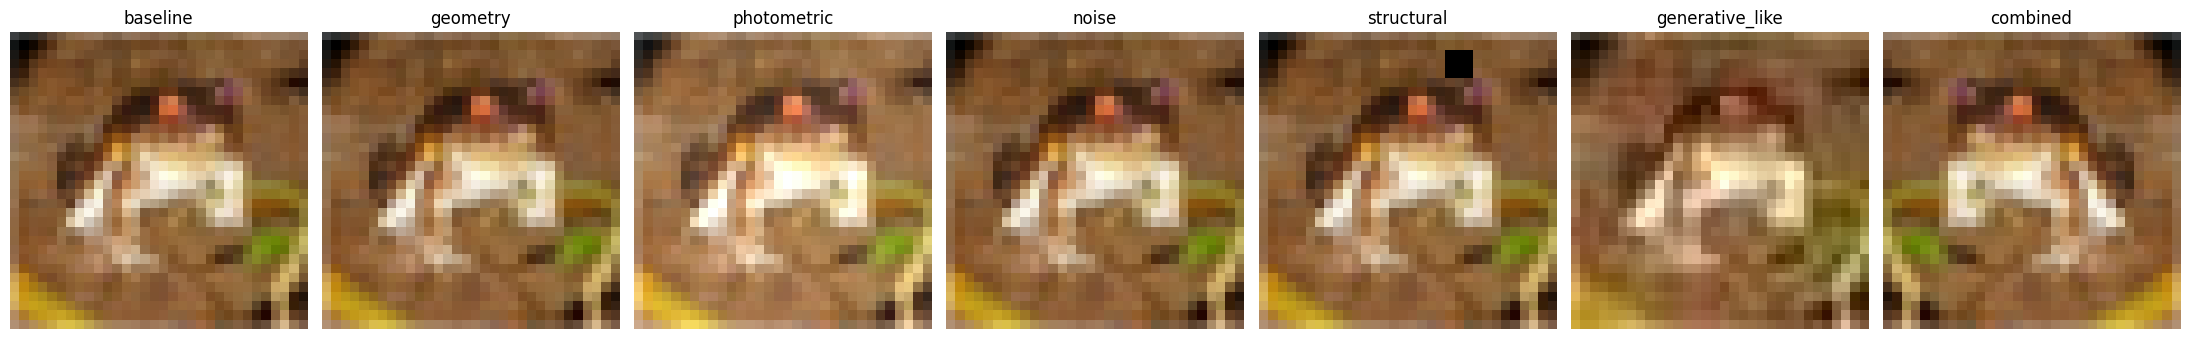

In [10]:
full_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)

test_raw = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True
)

save_augmentation_grid(full_train)

## Разбиение на обучающую и валидационную выборки

In [11]:
total_size = len(full_train)

val_size = int(total_size * VAL_SPLIT)

train_size = total_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset = random_split(
    full_train,
    [train_size, val_size],
    generator=generator
)

In [12]:
results = []

for aug_name, train_transform in augmentations.items():
    print("\n" + "="*60)
    print(f"TRAINING: {aug_name}")
    print("="*60)

    train_dataset = CIFAR10Albumentations(
        train_subset,
        train_transform
    )

    val_dataset = CIFAR10Albumentations(
        val_subset,
        robustness_transforms["clean"]
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    model = get_model()

    model, history = train_model(
        model,
        train_loader,
        val_loader
    )

    experiment_result = {
        "augmentation": aug_name
    }

    for corruption_name, corruption_transform in robustness_transforms.items():

        test_dataset = CIFAR10Albumentations(
            test_raw,
            corruption_transform
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=2
        )

        acc = evaluate_model(model, test_loader)

        experiment_result[corruption_name] = round(acc, 2)

        print(f"{corruption_name:<12}: {acc:.2f}%")

    robust_avg = np.mean([
        experiment_result["noise"],
        experiment_result["blur"],
        experiment_result["fog"],
        experiment_result["brightness"]
    ])

    experiment_result["robust_avg"] = round(robust_avg, 2)

    results.append(experiment_result)


TRAINING: baseline


Epoch 01 | Train Loss: 1.2867 | Val Loss: 1.0658 | Val Acc: 62.10%


Epoch 02 | Train Loss: 0.8048 | Val Loss: 0.9716 | Val Acc: 66.83%


Epoch 03 | Train Loss: 0.6157 | Val Loss: 0.6979 | Val Acc: 75.89%


Epoch 04 | Train Loss: 0.5026 | Val Loss: 0.6944 | Val Acc: 76.62%


...

Epoch 24 | Train Loss: 0.0394 | Val Loss: 0.3324 | Val Acc: 90.72%


Epoch 25 | Train Loss: 0.0339 | Val Loss: 0.3310 | Val Acc: 91.15%


Epoch 26 | Train Loss: 0.0335 | Val Loss: 0.3384 | Val Acc: 90.85%


Epoch 27 | Train Loss: 0.0261 | Val Loss: 0.3268 | Val Acc: 91.17%


Epoch 28 | Train Loss: 0.0235 | Val Loss: 0.3253 | Val Acc: 91.16%
Early stopping
clean       : 89.42%
noise       : 78.60%
blur        : 58.02%
fog         : 53.07%
brightness  : 88.30%


# Результаты эксперимента

In [13]:
results_df = pd.DataFrame(results)
results_df.to_csv(
    "robustness_results.csv",
    index=False
)
results_df

,augmentation,clean,noise,blur,fog,brightness,robust_avg
0,baseline,85.28,65.92,46.45,36.37,83.72,58.12
1,geometry,90.60,60.61,59.50,56.05,88.88,66.26
2,photometric,84.38,67.26,43.80,34.30,83.51,57.22
3,noise,80.19,73.92,68.74,58.58,78.38,69.90
4,structural,84.63,66.90,43.95,36.30,82.83,57.50
5,generative_like,85.05,75.24,72.85,68.30,83.33,74.93
6,combined,89.42,78.60,58.02,53.07,88.30,69.50


## Визуализации

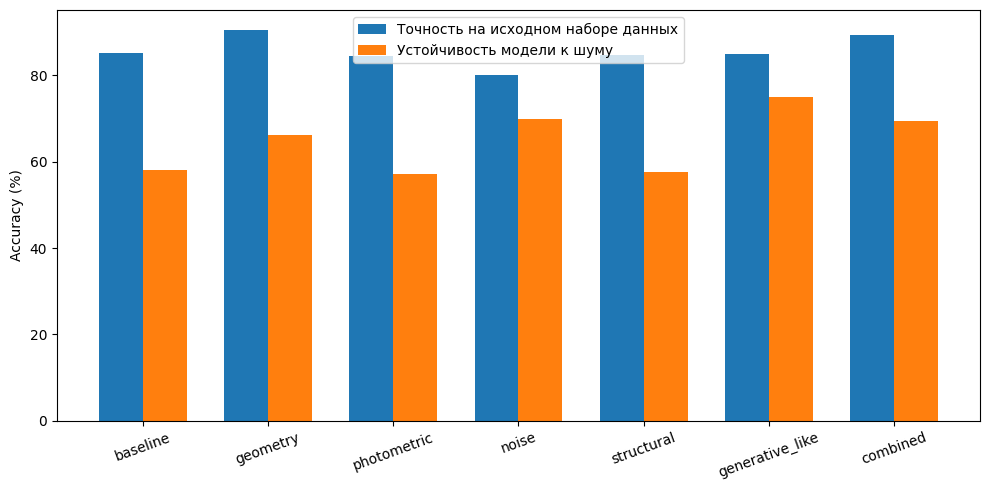

In [14]:
plt.figure(figsize=(10,5))
x = np.arange(len(results_df))
width = 0.35

plt.bar(
    x - width/2,
    results_df["clean"],
    width,
    label="Точность на исходном наборе данных"
)

plt.bar(
    x + width/2,
    results_df["robust_avg"],
    width,
    label="Устойчивость модели к шуму"
)

plt.xticks(
    x,
    results_df["augmentation"],
    rotation=20
)

plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.savefig(
    "clean_vs_robustness.png",
    dpi=300
)
plt.show()

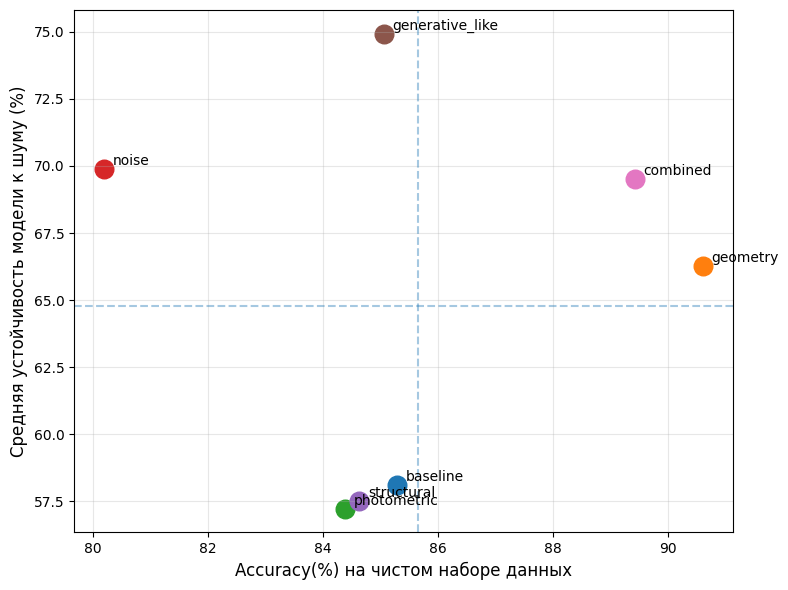

In [19]:
import matplotlib.pyplot as plt
import pandas as pd



plt.figure(figsize=(8, 6))

for _, row in results_df.iterrows():
    plt.scatter(
        row["clean"],
        row["robust_avg"],
        s=180
    )
    plt.text(
        row["clean"] + 0.15,
        row["robust_avg"] + 0.15,
        row["augmentation"],
        fontsize=10
    )


plt.xlabel("Accuracy(%) на чистом наборе данных", fontsize=12)
plt.ylabel("Средняя устойчивость модели к шуму (%)", fontsize=12)
plt.grid(alpha=0.3)


plt.axvline(
    results_df["clean"].mean(),
    linestyle="--",
    alpha=0.4
)

plt.axhline(
    results_df["robust_avg"].mean(),
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.savefig(
    "clean_vs_robustness.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()